# Notebook 3: Calculating the critical density if the system and comparing it with the mathematical predictions in 2 dimensions
## 3.1) Calculating the early cascade condition (2D)

We use the threshold framework of the accompanying PDF. The additive form is

$\kappa = q_s + q_\ell$

and, because `dynamics_2d_toggle` chooses one branch (short or long) per attempt through `p_long` and makes `m` attempts per fired trap, the form that matches the simulator is the mixture

$\kappa = m\left[(1-p_{\text{long}})\,q_s + p_{\text{long}}\,q_\ell\right].$

We use the mixture form throughout.

But in 2D, a long-range attempt at "distance" $k$ doesn't just have one possible target — it has an entire Chebyshev ring of candidate cells (see `distance_cells`), and the ball lands on **one cell chosen at random from that ring**. This doesn't change the *success* probability $p_{\text{succ\_long}}(k)$ itself, but it does mean $q_\ell$ has to be computed consistent with how `dynamics_2d_toggle` actually samples $k$ and mixes short/long via `p_long`, rather than assuming independent parallel attempts.

We compute $\kappa$ exactly as a sum over the landing-distance distribution (`kappa_exact`), check it against the simulator in 3.7b, and compare $\rho_{\text{onset}} = 1/\kappa$ with simulated cascade behaviour from `dynamics_2d_toggle`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Final 2D simulator (extracted unchanged from Notebook 0)
from Functions_final import dynamics_2d_toggle

In [3]:
def kappa_exact(pk, p_succ_long, p_succ_short, p_long=0.5, m=1, mode="additive"):
    """
    pk: array, pk[i] = P(k=i+1), sum = 1  (k=1 mass is wasted: long needs k>=2)
    qs = p_succ_short ; ql = sum_{k>=2} pk(k) * p_succ_long(k)
    additive: kappa = m(qs+ql)                     [PDF eq. 3]
    mixture : kappa = m((1-p_long)qs + p_long*ql)  [matches dynamics_2d_toggle]
    """
    k = np.arange(1, len(pk) + 1)
    ql = np.sum(pk[k >= 2] * p_succ_long(k[k >= 2]))
    qs = p_succ_short
    if mode == "mixture":
        qs, ql = (1 - p_long) * qs, p_long * ql
    return m * (qs + ql), m * qs, m * ql

def C0(rho, kappa):           # eq. 4
    return rho * kappa

def rho_onset(kappa):         # eq. 5
    return 1.0 / kappa

In [4]:
# --- model parameters: used by BOTH theory and simulation ---
f_k           = lambda rng: rng.geometric(p=0.3) + 1
p_succ_long   = lambda k: 0.2 * np.exp(-np.asarray(k, float) / 5)
p_succ_short  = 0.9
p_long        = 0.5
m             = 1

# --- theory side: pk and kappa (mixture form, as dynamics_2d_toggle uses) ---
Kmax  = 400
k_arr = np.arange(1, Kmax + 1)
pk    = np.where(k_arr >= 2, 0.3 * 0.7**(k_arr - 2), 0.0)   # must match f_k: sums to 1

kappa, q_s, q_l = kappa_exact(pk, p_succ_long, p_succ_short, p_long, m, mode="mixture")
kappa_add = kappa_exact(pk, p_succ_long, p_succ_short, p_long, m, mode="additive")[0]
print(f"mixture: kappa = {kappa:.4f}   q_s = {q_s:.4f}   q_l = {q_l:.4f}   rho_onset = {1/kappa:.4f}")
print(f"additive (PDF eq. 3, for comparison): kappa = {kappa_add:.4f}   rho_onset = {1/kappa_add:.4f}")

mixture: kappa = 0.4971   q_s = 0.4500   q_l = 0.0471   rho_onset = 2.0116
additive (PDF eq. 3, for comparison): kappa = 0.9942   rho_onset = 1.0058


## 3.2) Introducing density variables
At generation $n$, we define the following densities per lattice site:

| Symbol | Meaning |
|---|---|
| $\rho_{u,n}$ | Density of occupied, unfired traps |
| $\rho_{a,n}$ | Density of traps newly activated in generation $n$ |
| $\rho_{f,n}$ | Density of traps that have already fired |

We condition on the initially dropped ball activating one trap. A convenient initialization is

$$
\rho_{a,0} = \frac{1}{N}, \qquad \rho_{u,0} = \rho - \frac{1}{N}, \qquad \rho_{f,0} = 0.
$$

Here $N$ is the total number of sites (in 2D, $N = L^2$).

In [5]:
def init_densities(rho, L):
    N = L * L                 
    rho_a = 1.0 / N               # ρ_a,0: the one trap fired by the dropped ball
    rho_u = rho - 1.0 / N         # ρ_u,0: occupied, unfired
    rho_f = 0.0                   # ρ_f,0: nothing has fired before generation 0
    return rho_u, rho_a, rho_f

# example
rho_u, rho_a, rho_f = init_densities(rho=0.8, L=50)
print(rho_u, rho_a, rho_f)

0.7996000000000001 0.0004 0.0


## 3.3) Iterating the mean-field cascade

We assume that activation attempts are independent and uniformly distributed over the sites. The probability that an unfired trap receives at least one attempt from generation $n$ is then approximated by $1 - e^{-\kappa \rho_{a,n}}$. Therefore,

$$
\rho_{a,n+1} = \rho_{u,n}\left[1 - e^{-\kappa \rho_{a,n}}\right] \tag{7}
$$

$$
\rho_{u,n+1} = \rho_{u,n} - \rho_{a,n+1} \tag{8}
$$

$$
\rho_{f,n+1} = \rho_{f,n} + \rho_{a,n} \tag{9}
$$

We iterate until $\rho_{a,n}$ falls below a numerical tolerance, for example $10^{-10}$. The limiting fired density is denoted $\rho_{f,\infty}$.

In [6]:
def iterate_mean_field(rho, kappa, L, tol=1e-10, max_iter=100_000):
    """
    Iterates eqs. (7)-(9) from the initial condition in section 3.2.
    Returns rho_f_inf and the histories of (rho_u, rho_a, rho_f).
    """
    rho_u, rho_a, rho_f = init_densities(rho, L)
    hist = [(rho_u, rho_a, rho_f)]

    for n in range(max_iter):
        if rho_a < tol:
            break
        rho_a_new = rho_u * (1.0 - np.exp(-kappa * rho_a))   # eq. 7
        rho_u_new = rho_u - rho_a_new                        # eq. 8
        rho_f_new = rho_f + rho_a                            # eq. 9
        rho_u, rho_a, rho_f = rho_u_new, rho_a_new, rho_f_new
        hist.append((rho_u, rho_a, rho_f))

    rho_f_inf = rho_f + rho_a      # add the last (sub-tol) generation so nothing is dropped
    return rho_f_inf, np.array(hist)

# example, with the model's mixture kappa
rho_f_inf, hist = iterate_mean_field(rho=0.8, kappa=kappa, L=50)
F = rho_f_inf / 0.8                # eq. 10: fraction of traps fired
print(rho_f_inf, F, len(hist))

0.0006638138778616021 0.0008297673473270026 18


## 3.4) Solving the direct final-size equation

Under the same homogeneous-mixing and independent-attempt assumptions, the final fired fraction satisfies the self-consistency equation

$$
F = 1 - e^{-\rho \kappa F} = 1 - e^{-\rho (q_s + q_\ell) F}. \tag{11}
$$

It can be solved with a numerical root finder. Fixed-point iteration,

$$
F_{m+1} = 1 - e^{-\rho \kappa F_m}, \tag{12}
$$

can also be used from a small positive starting value, although it may converge slowly near the threshold.

In [7]:
from scipy.optimize import brentq

def F_final_size(rho, kappa, eps=1e-12):
    """Non-trivial root of F = 1 - exp(-rho*kappa*F), eq. 11. Returns 0 if rho*kappa <= 1."""
    lam = rho * kappa
    if lam <= 1.0:
        return 0.0                       # only the trivial root F = 0 exists
    g = lambda F: F - (1.0 - np.exp(-lam * F))
    return brentq(g, eps, 1.0)           # g(eps) < 0 and g(1) = exp(-lam) > 0

def F_fixed_point(rho, kappa, F0=1e-3, tol=1e-12, max_iter=1_000_000):
    """Fixed-point iteration, eq. 12."""
    F = F0
    for i in range(max_iter):
        F_new = 1.0 - np.exp(-rho * kappa * F)
        if abs(F_new - F) < tol:
            return F_new, i
        F = F_new
    return F, max_iter

# cross-check against the generation-by-generation iteration (section 3.3), using a test kappa > 1
kappa_test = 1.8
for rho_test in (0.4, 0.6, 0.8, 1.0):
    F_root = F_final_size(rho_test, kappa_test)
    F_fp, n_fp = F_fixed_point(rho_test, kappa_test)
    rho_f_inf, _ = iterate_mean_field(rho_test, kappa_test, L=200)
    print(f"rho={rho_test:.1f}  root={F_root:.6f}  fixed-pt={F_fp:.6f} ({n_fp} it)  "
          f"section3.3={rho_f_inf/rho_test:.6f}")

rho=0.4  root=0.000000  fixed-pt=0.000000 (60 it)  section3.3=0.000223
rho=0.6  root=0.144397  fixed-pt=0.144397 (358 it)  section3.3=0.144864
rho=0.8  root=0.541453  fixed-pt=0.541453 (80 it)  section3.3=0.541495
rho=1.0  root=0.732430  fixed-pt=0.732430 (48 it)  section3.3=0.732443


### Origin of the final-size equation

If a fraction $F$ of the initially present traps fires, the fired-trap density is $\rho F$. Each fired trap produces $\kappa$ attempts on average, so the mean number of attempts received by one site is

$$
\lambda = \kappa \rho F. \tag{13}
$$

With independent, uniformly distributed attempts, the number received by a given site is approximated by a Poisson random variable. Thus the probability of receiving no attempt is $e^{-\lambda}$, and the probability of receiving at least one is $1 - e^{-\lambda}$. Conditional on a trap being initially present, this latter probability is its probability of firing. Since $F$ is the final fraction fired, self-consistency requires

$$
F = 1 - e^{-\lambda} = 1 - e^{-\rho \kappa F}, \tag{14}
$$

which is Eq. (11).

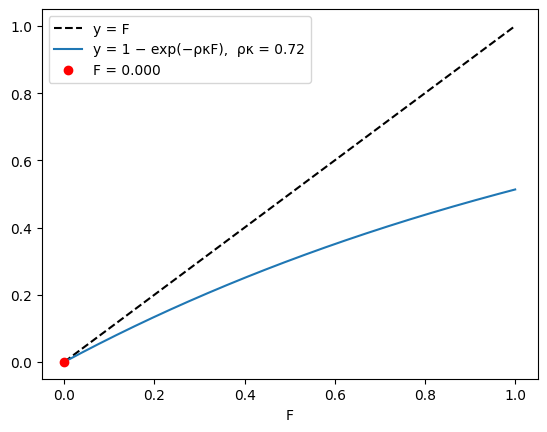

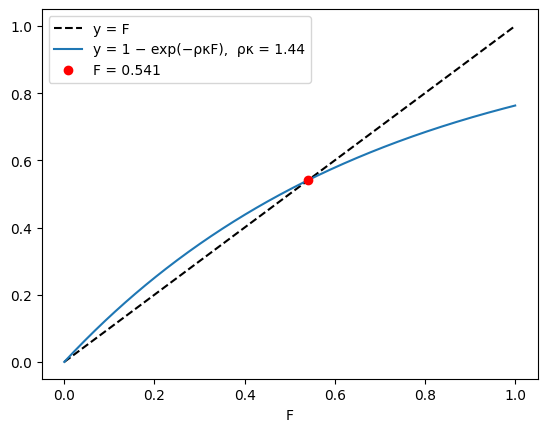

In [8]:
def plot_self_consistency(rho, kappa):
    F = np.linspace(0, 1, 400)
    plt.plot(F, F, 'k--', label='y = F')
    plt.plot(F, 1 - np.exp(-rho * kappa * F), label=f'y = 1 − exp(−ρκF),  ρκ = {rho*kappa:.2f}')
    F_star = F_final_size(rho, kappa)
    plt.plot(F_star, F_star, 'ro', label=f'F = {F_star:.3f}')
    plt.xlabel('F'); plt.legend(); plt.show()

plot_self_consistency(0.4, 1.8)   # ρκ < 1: only crossing at 0
plot_self_consistency(0.8, 1.8)   # ρκ > 1: second crossing

In [9]:
def check_poisson(rho, kappa, F, N=200_000, rng=None):
    rng = rng or np.random.default_rng()
    n_fired = int(rho * F * N)                      # fired traps
    n_attempts = int(round(kappa * n_fired))        # kappa attempts per fired trap
    targets = rng.integers(0, N, n_attempts)        # uniform, independent
    hit = np.zeros(N, dtype=bool); hit[targets] = True
    lam = kappa * rho * F
    print(f"simulated P(≥1 attempt) = {hit.mean():.4f}   1 − e^(−λ) = {1 - np.exp(-lam):.4f}")

check_poisson(0.8, 1.8, F=0.7)

simulated P(≥1 attempt) = 0.6341   1 − e^(−λ) = 0.6351


## 3.5) Scanning the density

We evaluate $F(\rho)$ over $0 \le \rho \le 1$ and record the smallest density at which the predicted fired fraction reaches 90%, 95%, 99% and 100%.

For a target $F^* < 1$, Eq. (11) can be rearranged to give

$$
\rho^* = -\frac{\ln(1 - F^*)}{\kappa F^*}. \tag{15}
$$

| Target | Required density | Status condition |
|---|---|---|
| 90% | $2.5584/\kappa$ | attainable only if $\rho^* \le 1$ |
| 95% | $3.1534/\kappa$ | attainable only if $\rho^* \le 1$ |
| 99% | $4.6517/\kappa$ | attainable only if $\rho^* \le 1$ |
| 100% | no finite value | exponential term remains positive |

Since each trap makes at most one nudge attempt and one ball attempt, $\kappa \le 2$. Consequently, this homogeneous-mixing approximation cannot reach the 90%, 95% or 99% targets within $0 \le \rho \le 1$. This is a limitation of the approximation, not a claim that a spatial chain can never fire completely.

kappa = 0.4971
  90%: rho* = 2.5584/kappa -> unattainable (rho* = 5.1466 > 1)
  95%: rho* = 3.1534/kappa -> unattainable (rho* = 6.3435 > 1)
  99%: rho* = 4.6517/kappa -> unattainable (rho* = 9.3575 > 1)
  100%: no finite value
kappa = 0.9942
  90%: rho* = 2.5584/kappa -> unattainable (rho* = 2.5733 > 1)
  95%: rho* = 3.1534/kappa -> unattainable (rho* = 3.1718 > 1)
  99%: rho* = 4.6517/kappa -> unattainable (rho* = 4.6788 > 1)
  100%: no finite value
kappa = 2.0000
  90%: rho* = 2.5584/kappa -> unattainable (rho* = 1.2792 > 1)
  95%: rho* = 3.1534/kappa -> unattainable (rho* = 1.5767 > 1)
  99%: rho* = 4.6517/kappa -> unattainable (rho* = 2.3258 > 1)
  100%: no finite value


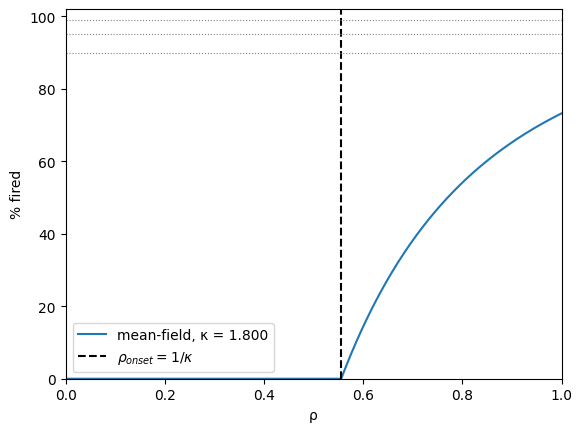

In [10]:
def rho_star(F_target, kappa):
    """Eq. 15: density needed for a target fired fraction F_target < 1."""
    return -np.log(1.0 - F_target) / (kappa * F_target)

def target_table(kappa, targets=(0.90, 0.95, 0.99)):
    print(f"kappa = {kappa:.4f}")
    for Ft in targets:
        r = rho_star(Ft, kappa)
        status = f"attainable (rho* = {r:.4f})" if r <= 1 else f"unattainable (rho* = {r:.4f} > 1)"
        print(f"  {100*Ft:.0f}%: rho* = {-np.log(1-Ft)/Ft:.4f}/kappa -> {status}")
    print("  100%: no finite value")

def scan_F(kappa, n=400):
    rhos = np.linspace(0, 1, n)
    F = np.array([F_final_size(r, kappa) for r in rhos])
    return rhos, F

def plot_scan(kappa, targets=(0.90, 0.95, 0.99)):
    rhos, F = scan_F(kappa)
    plt.plot(rhos, 100 * F, label=f'mean-field, κ = {kappa:.3f}')
    plt.axvline(1.0 / kappa, c='k', ls='--', label=r'$\rho_{onset}=1/\kappa$')
    for Ft in targets:
        plt.axhline(100 * Ft, c='gray', ls=':', lw=0.8)
    plt.xlim(0, 1); plt.ylim(0, 102)
    plt.xlabel('ρ'); plt.ylabel('% fired'); plt.legend(); plt.show()

# model parameters (kappa, kappa_add come from the parameters cell in 3.1)
target_table(kappa)       # mixture, matches the simulator: nothing reaches 90/95/99%, no onset in [0,1]
target_table(kappa_add)   # additive form (PDF eq. 3), for comparison
target_table(2.0)         # best case allowed by the PDF (kappa = 2)
plot_scan(1.8)            # illustrative kappa > 1

## 3.6) Reporting the model outputs

The model produces:

1. the onset estimate $\rho_{\text{onset}} = 1/\kappa$;
2. the predicted curve $100\,F(\rho)\%$;
3. the calculated or unattainable status of the 90%, 95%, 99% and 100% targets.

The assumptions are independent occupancy, homogeneous mixing, independent activation attempts, one ball per fired trap, and no re-firing.

In [11]:
def report_model(kappa, targets=(0.90, 0.95, 0.99), n=400):
    # 1. onset
    rho_on = 1.0 / kappa
    onset_txt = f"{rho_on:.4f}" + ("" if rho_on <= 1 else "  (> 1: no onset inside [0,1])")

    # 2. predicted curve
    rhos = np.linspace(0, 1, n)
    pct = 100 * np.array([F_final_size(r, kappa) for r in rhos])

    # 3. target status
    status = {}
    for Ft in targets:
        r = rho_star(Ft, kappa)
        status[f"{100*Ft:.0f}%"] = (r, r <= 1)
    status["100%"] = (np.inf, False)

    print(f"kappa = {kappa:.4f}")
    print(f"1. rho_onset = {onset_txt}")
    print(f"2. predicted % fired at rho=1: {pct[-1]:.2f}%")
    print("3. targets:")
    for name, (r, ok) in status.items():
        if name == "100%":
            print(f"   {name}: no finite value")
        else:
            print(f"   {name}: rho* = {r:.4f} -> {'attainable' if ok else 'unattainable (rho* > 1)'}")
    return rho_on, rhos, pct, status

rho_on, rhos, pct, status = report_model(kappa)

kappa = 0.4971
1. rho_onset = 2.0116  (> 1: no onset inside [0,1])
2. predicted % fired at rho=1: 0.00%
3. targets:
   90%: rho* = 5.1466 -> unattainable (rho* > 1)
   95%: rho* = 6.3435 -> unattainable (rho* > 1)
   99%: rho* = 9.3575 -> unattainable (rho* > 1)
   100%: no finite value


## 3.7) Comparing the mean-field predictions with the 2D simulation

The mean-field model of sections 3.1–3.6 makes three predictions. We now test each one against the 2D simulator (`dynamics_2d_toggle`), using the same parameters in theory and simulation: `f_k`, `p_succ_long`, `p_succ_short`, `p_long`, `m`. $\kappa$ is computed with the mixture form, because the simulator chooses one branch (short or long) per attempt through `p_long`.

| # | Quantity compared | Theory | Simulation | How it is compared |
|---|---|---|---|---|
| 1 | Mean number of new traps per fired trap | $\rho\kappa$ (eq. 4) | Number of traps fired in generation 1 (`steps=1`), averaged over many runs | $z$-score $(\text{sim}-\text{theory})/\text{SE}$ at several $\rho$; slope against $\rho$ gives $\kappa$ |
| 2 | Final fired fraction $F(\rho)$ | Root of $F = 1 - e^{-\rho\kappa F}$ (eq. 11) | Mean final fired fraction over many runs, `run(rho)` | Table and plot with error bars; RMSE; repeated for several lattice sizes $L$ |
| 3 | Onset density | $\rho_{\text{onset}} = 1/\kappa$ (eq. 5) | $\rho$ where $P(\text{macroscopic cascade})$ crosses 50% | Offset between the two; checked for several thresholds and $L$ |

**Expected outcome.** With the default parameters $\kappa < 1$, so theory and simulation both predict no macroscopic cascade, and comparisons 2 and 3 test whether the simulator reproduces this subcritical behaviour. Section 3.9 repeats them with $\kappa > 1$, where local attempts can break the homogeneous-mixing assumption: there we expect the simulated onset to lie above $1/\kappa$ and the simulated $F$ below the mean-field $F$, and the size of the gap is the result.

The model parameters were defined once in section 3.1 and are shared by theory and simulation.

### 3.7a) Simulation wrapper

To compare the theory with the simulator we define `run(rho)`. It runs one full 2D cascade with `dynamics_2d_toggle` and returns the final fired fraction: the number of fired (spent) traps divided by the number of traps present. Inert cells are excluded from the denominator, as in `pct_deactivated`. The seed trap counts as fired, so the result is never exactly 0 on a non-empty lattice.

All model parameters (`f_k`, `p_succ_long`, `p_succ_short`, `p_long`, `m`) are read from the parameters cell in 3.1, so the theory and the simulation always use the same values. Only $\rho$ varies. The step limit is set high enough that no cascade is cut off before it dies out.

In [12]:
def run(rho, L=50, steps=10_000, rng=None, **kw):
    """One full 2D cascade -> final fired fraction in [0, 1] (inert cells excluded)."""
    state = dynamics_2d_toggle(rho, f_k, p_succ_long,
                               p_succ_short=p_succ_short, p_long=p_long, m=m,
                               L=L, steps=steps, rng=rng, **kw)
    n_traps = np.sum(state != -1)
    return np.sum(state == -2) / n_traps if n_traps else 0.0

# smoke test
rng = np.random.default_rng(0)
for r in (0.2, 0.5, 0.8, 1.0):
    print(f"rho={r:.1f}  fired fraction = {run(r, rng=rng):.4f}")

rho=0.2  fired fraction = 0.0019
rho=0.5  fired fraction = 0.0016
rho=0.8  fired fraction = 0.0005
rho=1.0  fired fraction = 0.0004


### 3.7b) Comparison 1: mean number of new traps per fired trap

The first test checks $\kappa$ on its own, with no mean-field assumption. The theory predicts that one fired trap activates on average $\rho\kappa$ new traps (eq. 4). In the simulator we seed a single trap on a large lattice, run exactly one generation (`steps=1`), and count the traps fired in that generation. We average over many runs at several densities $\rho$.

For each $\rho$ we report the simulated mean, its standard error, the theoretical value $\rho\kappa$, and the $z$-score $(\text{sim} - \text{theory})/\text{SE}$. Agreement is $|z| \lesssim 2$–$3$ at every density. The slope of the simulated mean against $\rho$ is a direct estimate of $\kappa$. The lattice must be large and the seed away from the edge, so that clipped rings at the boundary do not bias the count.

In [13]:
def gen1_count(rho, L=201, **kw):
    """Traps fired in generation 1 from a single seed (steps=1)."""
    s = dynamics_2d_toggle(rho, f_k, p_succ_long,
                           p_succ_short=p_succ_short, p_long=p_long, m=m,
                           L=L, steps=1, **kw)
    return np.sum(s == 1)

def check_kappa(kappa_theory, rhos=(0.25, 0.5, 0.75, 1.0), n=2000, L=201, seed=1):
    rng = np.random.default_rng(seed)
    slopes_x, slopes_y = [], []
    for r in rhos:
        x = np.array([gen1_count(r, L=L, rng=rng) for _ in range(n)])
        mean, se = x.mean(), x.std(ddof=1) / np.sqrt(n)
        z = (mean - r * kappa_theory) / se
        print(f"rho={r:.2f}  sim={mean:.4f}±{se:.4f}  theory={r*kappa_theory:.4f}  z={z:+.2f}")
        slopes_x.append(r); slopes_y.append(mean)
    kappa_fit = np.sum(np.array(slopes_x) * np.array(slopes_y)) / np.sum(np.array(slopes_x) ** 2)  # fit y = κρ through origin
    print(f"fitted kappa = {kappa_fit:.4f}   theory = {kappa_theory:.4f}")

check_kappa(kappa)

rho=0.25  sim=0.1230±0.0073  theory=0.1243  z=-0.17
rho=0.50  sim=0.2335±0.0095  theory=0.2486  z=-1.59
rho=0.75  sim=0.3895±0.0109  theory=0.3728  z=+1.53
rho=1.00  sim=0.4830±0.0112  theory=0.4971  z=-1.26
fitted kappa = 0.4921   theory = 0.4971


### 3.7c) Comparison 2: final fired fraction $F(\rho)$

The second test compares the predicted final fired fraction, the root of $F = 1 - e^{-\rho\kappa F}$ (eq. 11), with the mean final fired fraction from many full simulations. We evaluate both on the same grid of densities and tabulate theory, simulation, standard error and difference. We summarise the disagreement with the root-mean-square error (RMSE), and plot the simulated points with error bars over the mean-field curve and the onset line $\rho_{\text{onset}} = 1/\kappa$.

The comparison is repeated for several lattice sizes $L$ to separate finite-size effects from the systematic difference caused by the mean-field assumptions.

kappa = 0.4971
1. rho_onset = 2.0116  (> 1: no onset inside [0,1])
2. predicted % fired at rho=1: 0.00%
3. targets:
   90%: rho* = 5.1466 -> unattainable (rho* > 1)
   95%: rho* = 6.3435 -> unattainable (rho* > 1)
   99%: rho* = 9.3575 -> unattainable (rho* > 1)
   100%: no finite value
L = 50, n = 100 runs per density, kappa = 0.4971
 rho   theory    sim ± se       diff
 0.10   0.0000   0.0041±0.0001   +0.0041
 0.20   0.0000   0.0023±0.0001   +0.0023
 0.30   0.0000   0.0015±0.0000   +0.0015
 0.40   0.0000   0.0013±0.0001   +0.0013
 0.50   0.0000   0.0011±0.0001   +0.0011
 0.60   0.0000   0.0010±0.0001   +0.0010
 0.70   0.0000   0.0008±0.0000   +0.0008
 0.80   0.0000   0.0008±0.0001   +0.0008
 0.90   0.0000   0.0008±0.0000   +0.0008
 1.00   0.0000   0.0007±0.0000   +0.0007
RMSE = 0.0017
L = 100, n = 100 runs per density, kappa = 0.4971
 rho   theory    sim ± se       diff
 0.10   0.0000   0.0010±0.0000   +0.0010
 0.20   0.0000   0.0006±0.0000   +0.0006
 0.30   0.0000   0.0004±0.0000   

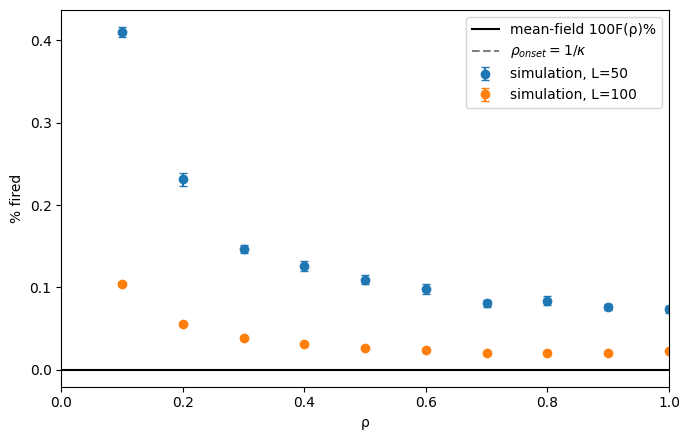

In [14]:
def compare_curve(kappa, run, rhos=np.linspace(0.1, 1.0, 10), n=100, L=50, seed=0):
    rng = np.random.default_rng(seed)
    th = np.array([F_final_size(r, kappa) for r in rhos])
    sims = np.array([[run(r, L=L, rng=rng) for _ in range(n)] for r in rhos])
    mean, se = sims.mean(1), sims.std(1, ddof=1) / np.sqrt(n)

    print(f"L = {L}, n = {n} runs per density, kappa = {kappa:.4f}")
    print(" rho   theory    sim ± se       diff")
    for r, t, a, e in zip(rhos, th, mean, se):
        print(f"{r:5.2f}  {t:7.4f}  {a:7.4f}±{e:.4f}  {a - t:+8.4f}")
    rmse = np.sqrt(np.mean((mean - th) ** 2))
    print(f"RMSE = {rmse:.4f}")
    return rhos, th, mean, se

def final_figure(kappa, run, Ls=(50, 100), rhos=np.linspace(0.1, 1.0, 10), n=100):
    rho_on, rho_grid, pct, _ = report_model(kappa)      # theory curve and onset
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(rho_grid, pct, 'k-', label='mean-field 100F(ρ)%')
    for L in Ls:
        _, _, mean, se = compare_curve(kappa, run, rhos=rhos, n=n, L=L)
        ax.errorbar(rhos, 100 * mean, yerr=100 * se, fmt='o', capsize=3, label=f'simulation, L={L}')
    ax.axvline(rho_on, c='gray', ls='--', label=r'$\rho_{onset}=1/\kappa$')
    ax.set_xlim(0, 1); ax.set_xlabel('ρ'); ax.set_ylabel('% fired')
    ax.legend(); plt.tight_layout(); plt.show()

final_figure(kappa, run)

### 3.7d) Comparison 3: onset density

The third test compares the predicted onset $\rho_{\text{onset}} = 1/\kappa$ (eq. 5) with the onset observed in the simulator. For each $\rho$ we estimate $P(\text{macroscopic})$, the fraction of runs whose final fired fraction exceeds a threshold. The simulated onset is the density where this probability crosses 50%. We report the offset from $1/\kappa$.

Because the threshold is arbitrary, the estimate is repeated for several thresholds (for example 1%, 5% and 10%) and several lattice sizes $L$. The onset is only meaningful if it is stable under these choices.

theory: rho_onset = 1/kappa = 2.0116   (> 1: no onset inside [0,1])
L=  50  thresh=0.01:  P never reaches 50% in [0.10, 1.00]   (max P = 0.00)
L=  50  thresh=0.05:  P never reaches 50% in [0.10, 1.00]   (max P = 0.00)
L=  50  thresh=0.10:  P never reaches 50% in [0.10, 1.00]   (max P = 0.00)
L= 100  thresh=0.01:  P never reaches 50% in [0.10, 1.00]   (max P = 0.00)
L= 100  thresh=0.05:  P never reaches 50% in [0.10, 1.00]   (max P = 0.00)
L= 100  thresh=0.10:  P never reaches 50% in [0.10, 1.00]   (max P = 0.00)


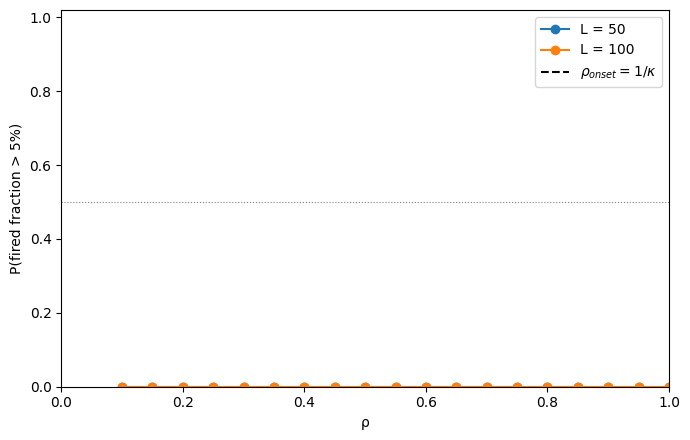

In [15]:
def sim_finals(run, rhos, L=50, n=100, seed=0):
    """Final fired fraction for n runs at each density -> array (len(rhos), n)."""
    rng = np.random.default_rng(seed)
    return np.array([[run(r, L=L, rng=rng) for _ in range(n)] for r in rhos])

def onset_crossing(rhos, p, level=0.5):
    """Density where p first reaches `level` (linear interpolation). NaN if it never does."""
    idx = np.where(p >= level)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return rhos[0]                                   # already above level at the lowest density
    r0, r1, p0, p1 = rhos[i - 1], rhos[i], p[i - 1], p[i]
    return r0 + (level - p0) * (r1 - r0) / (p1 - p0)

def onset_comparison(kappa, run, rhos=np.linspace(0.1, 1.0, 19), Ls=(50, 100),
                     threshs=(0.01, 0.05, 0.10), n=100):
    rho_th = 1.0 / kappa
    print(f"theory: rho_onset = 1/kappa = {rho_th:.4f}"
          + ("" if rho_th <= 1 else "   (> 1: no onset inside [0,1])"))
    results = {}
    for L in Ls:
        finals = sim_finals(run, rhos, L=L, n=n)
        for thr in threshs:
            p = (finals > thr).mean(axis=1)              # P(macroscopic cascade) at each rho
            rho_sim = onset_crossing(rhos, p)
            results[(L, thr)] = (p, rho_sim)
            if np.isnan(rho_sim):
                print(f"L={L:4d}  thresh={thr:.2f}:  P never reaches 50% in [{rhos[0]:.2f}, {rhos[-1]:.2f}]"
                      f"   (max P = {p.max():.2f})")
            else:
                print(f"L={L:4d}  thresh={thr:.2f}:  simulated onset = {rho_sim:.4f}"
                      f"   offset from 1/kappa = {rho_sim - rho_th:+.4f}")
    return rhos, results

def plot_onset(kappa, rhos, results, thresh=0.05):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for (L, thr), (p, _) in results.items():
        if thr == thresh:
            ax.plot(rhos, p, 'o-', label=f'L = {L}')
    ax.axhline(0.5, c='gray', ls=':', lw=0.8)
    ax.axvline(1.0 / kappa, c='k', ls='--', label=r'$\rho_{onset}=1/\kappa$')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel('ρ'); ax.set_ylabel(f'P(fired fraction > {thresh:.0%})')
    ax.legend(); plt.tight_layout(); plt.show()

rhos_o, results = onset_comparison(kappa, run)
plot_onset(kappa, rhos_o, results, thresh=0.05)

## 3.8) Conclusions

**Parameters used.** `p_succ_short` = 0.9, `p_long` = 0.5, `m` = 1, `f_k` = 1 + Geometric(0.3), `p_succ_long(k)` = 0.2·exp(−k/5). In the mixture form these give $\kappa$ = 0.4971 ($q_s$ = 0.4500, $q_\ell$ = 0.0471) and $\rho_{\text{onset}} = 1/\kappa$ = 2.012.

**1. The branching ratio $\kappa$ is correct.** The mean number of traps fired in the first generation agrees with $\rho\kappa$ at every density tested ($|z| \le 1.59$; fitted $\kappa$ = 0.4921 against the theoretical 0.4971; the check is seeded, so these values reproduce). The quantities $q_s$ and $q_\ell$, the $k \ge 2$ rule for long-range attempts, and the mixture weighting by $p_{\text{long}}$ therefore describe the simulator correctly.

**2. The final-size curve agrees: no macroscopic cascade.** Since $\rho\kappa < 1$ for every $\rho \le 1$, the mean-field model predicts $F = 0$ everywhere (0% fired at $\rho = 1$). The simulation gives a final fired fraction of 0.0007 at $L = 50$ and 0.0002 at $L = 100$ at $\rho = 1$ (RMSE = 0.0017 and 0.0004 respectively), which corresponds to the seed trap plus about one further trap, and it falls as $L$ increases. Cascades die out within one or two generations.

**3. The predicted onset is not reached, and none is observed.** The mean-field onset is $\rho_{\text{onset}}$ = 2.012, outside $[0,1]$. In the simulation P(macroscopic cascade) is 0 at every density tested, for thresholds of 1%, 5% and 10% and for $L$ = 50 and 100, so the result does not depend on the threshold or on the lattice size.

**Interpretation.** In the mixture form each fired trap makes one attempt that is short-range with probability $1-p_{\text{long}}$ (success probability 0.9) or long-range with probability $p_{\text{long}}$ (success probability at most 0.2). For $m = 1$ this gives $\kappa = (1-p_{\text{long}})\cdot 0.9 + p_{\text{long}}\,E[p_{\text{succ,long}}(k)] \le 0.9 < 1$. With these parameters the process is therefore subcritical, and the mean-field branching-process picture and the 2D simulation agree.

**Limits of this result.** The agreement above is in the subcritical regime, where both the theory and the simulation give essentially no cascade; it does not yet test the final-size curve or the onset density. The tests used $L$ = 50 and 100, 100 runs per density, and thresholds of 1%, 5% and 10%. Section 3.9 tests the supercritical regime.

## 3.9) Supercritical regime ($\kappa > 1$)

With $m = 1$ the process is subcritical for every $\rho$, so sections 3.7a–d cannot distinguish a correct theory from a trivial one. To reach $\rho\kappa > 1$ inside $[0,1]$ we raise the number of attempts per fired trap to $m = 5$ and make every attempt long-range ($p_{\text{long}} = 1$) with a distance-independent success probability of 0.9. Short-range attempts are no use here: they can only reach the few cells next to the firing trap, most of which are already spent. In the mixture form this gives $\kappa = m\,p_{\text{long}}\,E[p_{\text{succ,long}}(k)] = 5 \times 0.9 = 4.5$ and $\rho_{\text{onset}} = 1/\kappa \approx 0.22$.

**This cell overwrites the model parameters.** `run`, `gen1_count` and the plotting helpers read `p_succ_long`, `p_long`, `m` and `kappa` from the global namespace, so section 3.9 must be the last section run. The three comparisons of 3.7 are repeated unchanged.

In [16]:
# --- supercritical parameters (overwrite the globals read by run, gen1_count, ...) ---
p_succ_long = lambda k: 0.9 + 0 * np.asarray(k, float)
p_long, m = 1.0, 5

kappa, q_s, q_l = kappa_exact(pk, p_succ_long, p_succ_short, p_long, m, mode="mixture")
print(f"kappa = {kappa:.3f}   rho_onset = {1/kappa:.3f}")
report_model(kappa)

# comparison 1: first generation, ~ rho*kappa
check_kappa(kappa)

kappa = 4.500   rho_onset = 0.222
kappa = 4.5000
1. rho_onset = 0.2222
2. predicted % fired at rho=1: 98.83%
3. targets:
   90%: rho* = 0.5685 -> attainable
   95%: rho* = 0.7008 -> attainable
   99%: rho* = 1.0337 -> unattainable (rho* > 1)
   100%: no finite value
rho=0.25  sim=1.0800±0.0202  theory=1.1250  z=-2.23
rho=0.50  sim=2.1985±0.0247  theory=2.2500  z=-2.08
rho=0.75  sim=3.3395±0.0237  theory=3.3750  z=-1.50
rho=1.00  sim=4.4415±0.0156  theory=4.5000  z=-3.75
fitted kappa = 4.4349   theory = 4.5000


kappa = 4.5000
1. rho_onset = 0.2222
2. predicted % fired at rho=1: 98.83%
3. targets:
   90%: rho* = 0.5685 -> attainable
   95%: rho* = 0.7008 -> attainable
   99%: rho* = 1.0337 -> unattainable (rho* > 1)
   100%: no finite value
L = 50, n = 50 runs per density, kappa = 4.5000
 rho   theory    sim ± se       diff
 0.10   0.0000   0.0078±0.0009   +0.0078
 0.20   0.0000   0.0109±0.0019   +0.0109
 0.30   0.4693   0.1311±0.0220   -0.3382
 0.40   0.7324   0.4954±0.0443   -0.2370
 0.50   0.8534   0.7531±0.0359   -0.1003
 0.60   0.9156   0.8700±0.0254   -0.0456
 0.70   0.9498   0.9438±0.0010   -0.0060
 0.80   0.9695   0.9653±0.0007   -0.0042
 0.90   0.9812   0.9774±0.0005   -0.0038
 1.00   0.9883   0.9858±0.0003   -0.0024
RMSE = 0.1353


KeyboardInterrupt: 

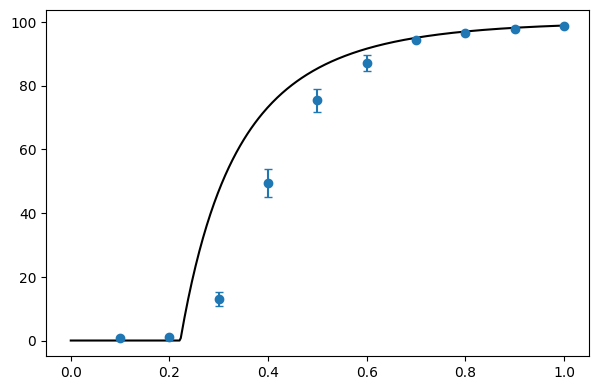

In [17]:
# comparison 2: final fired fraction F(rho)
final_figure(kappa, run, Ls=(50, 100), n=50)

theory: rho_onset = 1/kappa = 0.2222


L=  50  thresh=0.01:  simulated onset = 0.2200   offset from 1/kappa = -0.0022
L=  50  thresh=0.05:  simulated onset = 0.3188   offset from 1/kappa = +0.0965
L=  50  thresh=0.10:  simulated onset = 0.3222   offset from 1/kappa = +0.1000


L= 100  thresh=0.01:  simulated onset = 0.3100   offset from 1/kappa = +0.0878
L= 100  thresh=0.05:  simulated onset = 0.3200   offset from 1/kappa = +0.0978
L= 100  thresh=0.10:  simulated onset = 0.3262   offset from 1/kappa = +0.1040


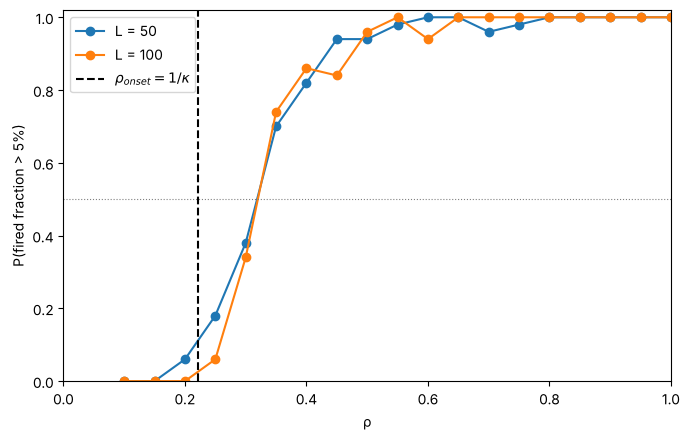

In [ ]:
# comparison 3: onset density
rhos_o, results = onset_comparison(kappa, run, Ls=(50, 100), n=50)
plot_onset(kappa, rhos_o, results, thresh=0.05)

## 3.10) Conclusions of the supercritical test

**Parameters used.** $m = 5$, $p_{\text{long}} = 1$, $p_{\text{succ,long}}(k) = 0.9$ for all $k$, $f_k = 1 + \text{Geometric}(0.3)$. The mixture form gives $\kappa = 4.5$, $\rho_{\text{onset}} = 0.222$ and a mean-field final fraction $F(1) = 98.8\%$. Lattices $L$ = 50 and 100, 50 runs per density.

**1. $\kappa$ is correct to about 1.5%.** The mean number of traps fired in generation 1 is 1.08, 2.20, 3.34 and 4.44 at $\rho$ = 0.25, 0.5, 0.75, 1 against $\rho\kappa$ = 1.13, 2.25, 3.38, 4.50, and the fitted $\kappa$ is 4.435. The simulated values lie systematically slightly below the theory ($|z|$ up to 3.75) because the simulator merges several hits on the same trap within a generation (`set(new_fires)`), so the number of distinct new traps is slightly below the number of successful attempts. The effect is small in 2D, where the ring at distance $k$ has $8k$ sites, and it is much larger in 1D, where the ring has only 2 sites (see Notebook 4, section 4.10).

**2. The final-size curve agrees at high density and overestimates it near the onset.** The simulated mean fired fraction is within 0.01 of the mean-field value for $\rho \ge 0.7$ (0.9858 against 0.9883 at $\rho = 1$, $L = 50$; 0.9871 at $L = 100$). Below that the theory overestimates: at $\rho = 0.3$ it predicts 0.469 and the simulation gives 0.131 ($L$ = 50) and 0.113 ($L$ = 100); at $\rho = 0.5$ it predicts 0.853 and the simulation gives 0.753 and 0.759. The RMSE is 0.135 ($L$ = 50) and 0.131 ($L$ = 100), dominated by $\rho$ = 0.3–0.5, and barely changes with $L$, so the discrepancy is not a finite-size effect. The simulated values at $\rho = 0.1$ and 0.2 (0.008 and 0.011 at $L$ = 50) are the seed trap divided by the few traps present, and fall with $L$.

**3. The onset is shifted to higher density by about 0.1.** Taking the density at which P(fired fraction > threshold) crosses 50%, the simulated onset is 0.319 and 0.322 for the 5% and 10% thresholds at $L$ = 50, and 0.320 and 0.326 at $L$ = 100, against $1/\kappa = 0.222$: an offset of +0.10, stable across thresholds and lattice sizes. The 1% threshold gives 0.220 at $L$ = 50 and 0.310 at $L$ = 100, so at 1% it is not reliable (at low density a single seed trap is already a large fraction of the traps present).

**Interpretation (a hypothesis, not tested here).** The result is in line with the spatial-correlation argument of section 3.7: attempts are local (the mean landing distance is $E[k] \approx 4.3$ sites), so the mean-field model, which assumes every attempt lands on a uniformly random site, is too optimistic near the onset, where the cascade is a thin front and the sites within reach behind it are already spent. Far above the onset almost every site is occupied and reachable, and the two agree. In 1D the same test fails far more strongly (Notebook 4, section 4.10), which is consistent with this explanation: in 2D each fired trap has far more fresh sites within reach than in 1D, where the site it came from is always one of its two neighbours.

**Limits.** One parameter set was tested, with $L$ = 50 and 100, 50 runs per density and thresholds of 1%, 5% and 10%. The explanation above has not been tested directly. A test would replace $f_k$ by a distribution of $k$ that is uniform over the whole lattice and check whether the agreement near the onset then improves.

In [ ]:
import os
os.makedirs('figures', exist_ok=True)

DIM, L_SIM, N_RUNS = '2D', 100, 50       

rho_grid = np.linspace(0, 1, 400)
theory = [F_final_size(r, kappa) for r in rho_grid]

# same call and seed as the supercritical section, so the values match the printed table
rhos_f, th, mean, se = compare_curve(kappa, run, L=L_SIM, n=N_RUNS)
np.savez(f'figures/data_{DIM}.npz', rhos=rhos_f, mean=mean, se=se, kappa=kappa)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rho_grid, theory, 'k-', lw=2, label='mean-field F(ρ)')
ax.errorbar(rhos_f, mean, yerr=se, fmt='o-', capsize=3, label=f'simulation, {DIM}, L = {L_SIM}')
ax.axvline(1 / kappa, c='gray', ls='--', label=r'$\rho_{onset}=1/\kappa$')
ax.set_xlim(0, 1); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('ρ'); ax.set_ylabel('final fired fraction')
ax.set_title(f'κ = {kappa:.2f}: theory vs simulation ({DIM})')
ax.legend(); plt.tight_layout()
plt.savefig(f'figures/final_fraction_{DIM}.png', dpi=200, bbox_inches='tight')
plt.show()